# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [8]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [9]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [10]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [11]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [12]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [13]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

We can plot the output, comparing signal and background:

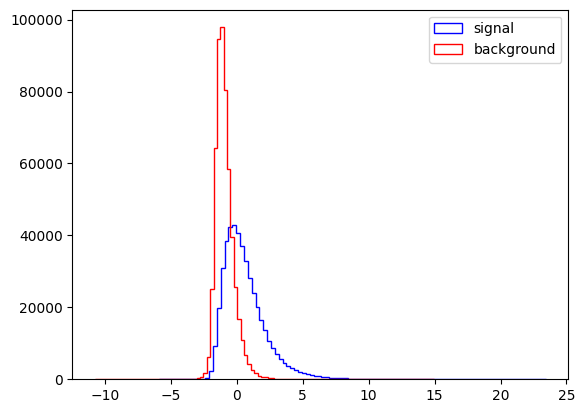

In [14]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

In [15]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, 
                           n_informative=5, n_redundant=2, 
                           n_classes=2, random_state=42)

# Split it into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)




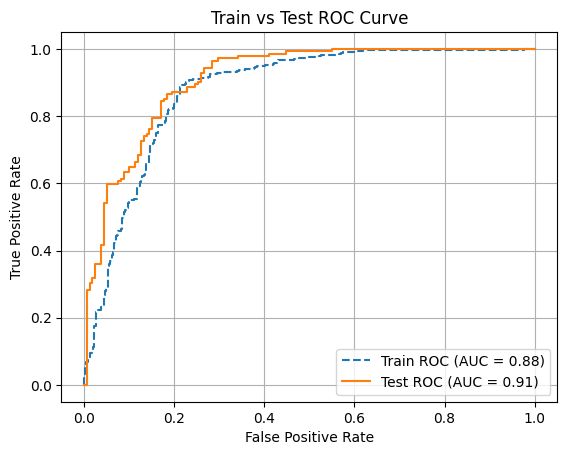

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fisher = LinearDiscriminantAnalysis()
fisher.fit(X_train, y_train)

train_scores = fisher.decision_function(X_train)
test_scores = fisher.decision_function(X_test)

fpr_train, tpr_train, _ = roc_curve(y_train, train_scores)
fpr_test, tpr_test, _ = roc_curve(y_test, test_scores)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

plt.figure()
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.2f})', linestyle='--')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {auc_test:.2f})', linestyle='-')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Train vs Test ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [17]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import numpy as np

# Raw data
X_raw, y = make_classification(n_samples=1000, n_features=10, 
                                n_informative=5, n_redundant=2, 
                                n_classes=2, random_state=42)

X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=42
)


In [18]:
# Feature engineering with PCA
pca = PCA(n_components=5)
X_feat_train = pca.fit_transform(X_raw_train)
X_feat_test = pca.transform(X_raw_test)


In [19]:
# Concatenate raw + features
X_comb_train = np.hstack((X_raw_train, X_feat_train))
X_comb_test = np.hstack((X_raw_test, X_feat_test))


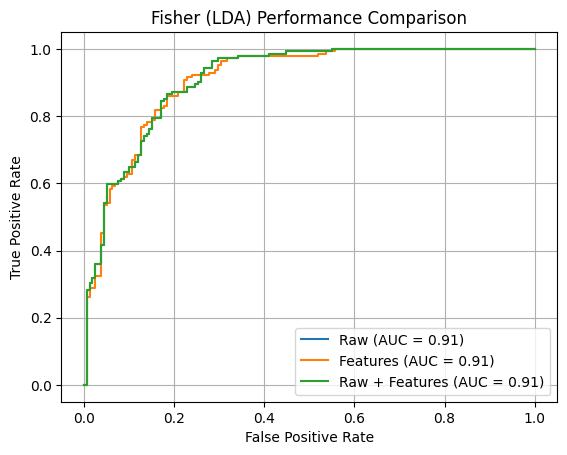

In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

inputs = {
    "Raw": (X_raw_train, X_raw_test),
    "Features": (X_feat_train, X_feat_test),
    "Raw + Features": (X_comb_train, X_comb_test)
}

plt.figure()

for label, (X_tr, X_te) in inputs.items():
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_tr, y_train)
    scores = lda.decision_function(X_te)
    
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher (LDA) Performance Comparison")
plt.legend()
plt.grid(True)
plt.show()


### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [30]:
# Part A
# - Logistic Regression

# - Random Forest Classifier

# - K-Nearest Neighbors (KNN)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [31]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [32]:
# Part B 
from sklearn.metrics import accuracy_score, recall_score, precision_score

def evaluate_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    return {
        'Accuracy': accuracy,
        'Recall': recall,
        'Precision': precision
    }


In [33]:
results_logistic = evaluate_classifier(LogisticRegression(), X_train, y_train, X_test, y_test)
results_rf = evaluate_classifier(RandomForestClassifier(), X_train, y_train, X_test, y_test)
results_knn = evaluate_classifier(KNeighborsClassifier(), X_train, y_train, X_test, y_test)

In [34]:
def compute_significance(y_true, y_pred):
    NS = sum((y_true == 1) & (y_pred == 1))  # True Positives
    NB = sum((y_true == 0) & (y_pred == 1))  # False Positives
    if NS + NB == 0:
        return 0
    return NS / ((NS + NB) ** 0.5)


In [35]:
# Train best model
best_clf = RandomForestClassifier()
best_clf.fit(X_train, y_train)
y_pred_best = best_clf.predict(X_test)

# Compute significance
sigma_s = compute_significance(y_test, y_pred_best)
print(f"Maximal Significance (σS): {sigma_s}")


Maximal Significance (σS): 11.166666666666666


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

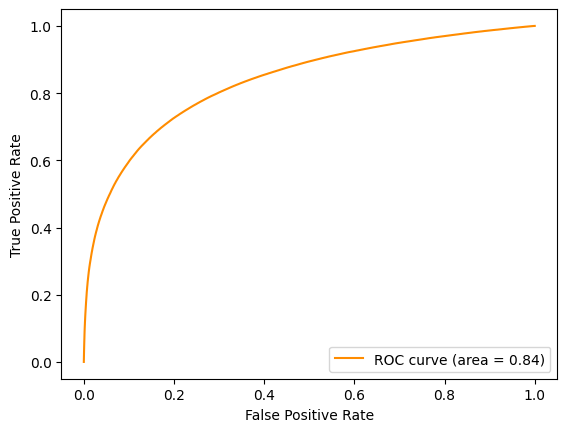

In [26]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
import numpy as np

def compute_max_significance(y_true, y_scores):
    """Find the max significance S/sqrt(B) across thresholds."""
    thresholds = np.linspace(0, 1, 100)
    max_sig = 0
    for thresh in thresholds:
        preds = (y_scores > thresh).astype(int)
        S = np.sum((preds == 1) & (y_true == 1))
        B = np.sum((preds == 1) & (y_true == 0))
        if B > 0:
            significance = S / np.sqrt(B)
            max_sig = max(max_sig, significance)
    return max_sig


In [28]:
def evaluate_model(clf, X_train, X_test, y_train, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_scores = clf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall (TPR)': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_scores),
        'Max Significance': compute_max_significance(y_test, y_scores)
    }


In [29]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

clf = RandomForestClassifier(random_state=42)

results = {
    'Raw': evaluate_model(clf, X_raw_train, X_raw_test, y_train, y_test),
    'Features': evaluate_model(clf, X_feat_train, X_feat_test, y_train, y_test),
    'Raw + Features': evaluate_model(clf, X_comb_train, X_comb_test, y_train, y_test)
}

df_results = pd.DataFrame(results).T  # Transpose to get scenarios as rows
df_results


,Accuracy,Precision,Recall (TPR),F1 Score,AUC,Max Significance
Raw,0.940000,0.942857,0.929577,0.936170,0.985626,92.0
Features,0.933333,0.948529,0.908451,0.928058,0.988099,128.0
Raw + Features,0.936667,0.942446,0.922535,0.932384,0.993292,120.0
